In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from __future__ import annotations

import os
from pathlib import Path
import pandas as pd

from utils import (
    resolve_log_path, parse_final_test_metrics, build_row, 
    calc_confusion_matrix, calc_performance,
    viz_tim_bar_plot, viz_sample_keys, viz_sample_multimodel_keys, viz_perf_distr_multi_model_metric
    )

# Performance

In [3]:
dataset_root = Path(os.path.join(os.environ.get('SCRATCH'),'zeroflood','ZeroFlood'))
model_root = Path(os.path.join(os.environ.get('SCRATCH'),'zeroflood','models'))

df = pd.read_csv(os.path.join(dataset_root, 'metadata', 'info_val.csv'), delimiter='\t')
df = calc_confusion_matrix(df, 'test', print_summary=False, print_hist=False)

df_unet = calc_performance(df.copy(), dataset_root/'val', model_root/'zeroflood-baseline-unet')
# df_vit = calc_performance(df.copy(), dataset_root/'val', model_root/'zeroflood-baseline-vit')

# df_croma = calc_performance(df.copy(), dataset_root/'val', model_root/'zeroflood-gfm-croma')
df_dofa = calc_performance(df.copy(), dataset_root/'val', model_root/'zeroflood-gfm-dofa')
# df_ssl4eo_mae = calc_performance(df.copy(), dataset_root/'val', model_root/'zeroflood-gfm-ssl4eo-mae')

df_terramind = calc_performance(df.copy(), dataset_root/'val', model_root/'zeroflood-gfm-terramind')
df_terramind_tim = calc_performance(df.copy(), dataset_root/'val', model_root/'zeroflood-gfm-terramind-tim')

df_dict = {
    'UNet':           (df_unet,          'white',  ''),
    # 'SSL4EO-MAE':     (df_ssl4eo_mae,    'lightgrey',  ''),
    # 'Croma': (df_croma, 'lightgrey',  ''),
    'DOFA': (df_dofa, 'lightgrey',  ''),
    'TerraMind':      (df_terramind,     '#00658B',  ''),
    'TerraMind-TiM':  (df_terramind_tim, '#00658B',  '..'),
}

100%|██████████| 226/226 [00:11<00:00, 19.37it/s]


## Table - mIoU / F1 / HR / TAR

In [4]:
RUN_DIRS = {
    "UNet": "../script/training/unet_encoder/output",
    "ViT": "../script/training/vit_scratch/output",

    "SSL4EO-MAE": "../script/training/ssl4eo_mae_sar/output",
    "CROMA": "../script/training/croma_sar/output",
    "DOFA": "../script/training/dofa/output",

    "TerraMind": "../script/training/terramind_base/output",

    "TerraMind-TiM-s": "../script/training/terramind_base_tim/output/s",
    "TerraMind-TiM-l": "../script/training/terramind_base_tim/output/l",
    "TerraMind-TiM-d": "../script/training/terramind_base_tim/output/d",

    "TerraMind-TiM-sl": "../script/training/terramind_base_tim/output/sl",
    "TerraMind-TiM-ls": "../script/training/terramind_base_tim/output/ls",
    "TerraMind-TiM-sd": "../script/training/terramind_base_tim/output/sd",
    "TerraMind-TiM-ds": "../script/training/terramind_base_tim/output/ds",
    "TerraMind-TiM-ld": "../script/training/terramind_base_tim/output/ld",
    "TerraMind-TiM-dl": "../script/training/terramind_base_tim/output/dl",

    "TerraMind-TiM-sld": "../script/training/terramind_base_tim/output/sld",
    "TerraMind-TiM-sdl": "../script/training/terramind_base_tim/output/sdl",
    "TerraMind-TiM-lsd": "../script/training/terramind_base_tim/output/lsd",
    "TerraMind-TiM-lds": "../script/training/terramind_base_tim/output/lds",
    "TerraMind-TiM-dls": "../script/training/terramind_base_tim/output/dls",
    "TerraMind-TiM-dsl": "../script/training/terramind_base_tim/output/dsl",
}

In [91]:
results = pd.DataFrame(columns=['Model','mIoU','F1','Hit Rate','True Alarm','T_train','T_test'])
for run_name, run_path in RUN_DIRS.items():
    log_path = resolve_log_path(run_path)
    parsed = parse_final_test_metrics(log_path)
    values = build_row(run_name, parsed)
    results.loc[len(results)] = [run_name]+values+[parsed['T_train'],parsed['T_test']]
results

,Model,mIoU,F1,Hit Rate,True Alarm,T_train,T_test
0,UNet,80.42,84.66,81.00,88.67,0 days 03:07:23,0 days 00:00:05
1,ViT,80.35,84.64,81.46,88.08,0 days 06:17:04,0 days 00:00:06
2,SSL4EO-MAE,81.09,85.23,81.39,89.44,0 days 03:35:33,0 days 00:00:04
3,CROMA,79.30,83.63,79.72,87.95,0 days 06:42:54,0 days 00:00:17
4,DOFA,82.86,86.90,84.80,89.11,0 days 04:07:30,0 days 00:00:05
5,TerraMind,84.56,88.36,86.77,90.02,0 days 04:21:24,0 days 00:00:06
6,TerraMind-TiM-s,85.31,88.97,87.37,90.64,0 days 09:28:30,0 days 00:00:16
7,TerraMind-TiM-l,85.02,88.77,87.64,89.91,0 days 08:47:24,0 days 00:00:15
8,TerraMind-TiM-d,85.22,88.91,87.34,90.53,0 days 09:30:45,0 days 00:00:15
9,TerraMind-TiM-sl,84.34,88.22,87.26,89.21,0 days 14:11:14,0 days 00:00:24


## Plots - TiM Sets

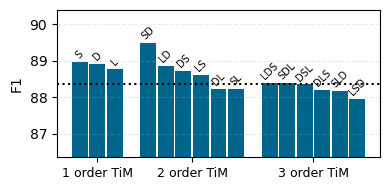

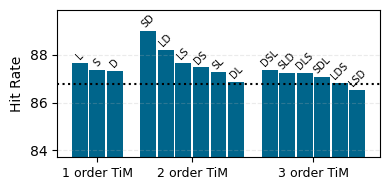

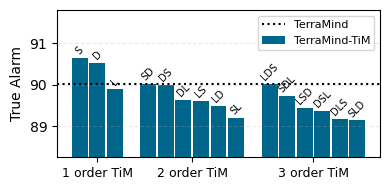

In [6]:
for metric in ['F1','Hit Rate','True Alarm']:
    tm_results = results.iloc[5:][['Model',metric]].reset_index(drop=True)

    tm_results.loc[1:, 'Model'] = tm_results.loc[1:, 'Model'].str.replace('TerraMind-TiM-', '', regex=False).str.upper()

    tm_results_base = tm_results.iloc[0]
    tm_results_1 = tm_results.iloc[1:4].sort_values(metric, ascending=False)
    tm_results_2 = tm_results.iloc[4:10].sort_values(metric, ascending=False)
    tm_results_3 = tm_results.iloc[10:].sort_values(metric, ascending=False)

    # ref, vmax, vmin = tm_results_base[metric], tm_results.iloc[1:][metric].max(), tm_results.iloc[1:][metric].min()
    # padded_max = vmax + (vmax - ref) * 0.5
    # padded_min = vmin - (ref - vmin) * 0.5

    groups = [
        ('TerraMind', tm_results_base, 'black'),
        ('1 order TiM', tm_results_1, '#00658B'),
        ('2 order TiM', tm_results_2, '#00658B'),
        ('3 order TiM', tm_results_3, '#00658B'),
    ]

    viz_tim_bar_plot(groups, metric, figsize=(4,2), legend_true= metric == 'True Alarm')

## water in risk area

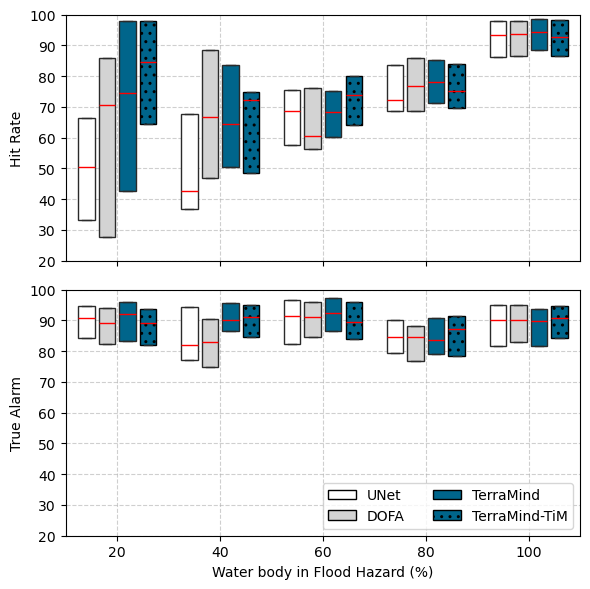

In [7]:
# plot_df = viz_perf_distr_multi_model(df_dict, col_x='Water body in Flood Hazard (%)', col_y='F1',ylim=(30,100), figsize=(6,3))
# plot_df = viz_perf_distr_multi_model(df_dict, col_x='Water body in Flood Hazard (%)', col_y='Hit Rate', ylim=(20,100), figsize=(6,3))
# plot_df = viz_perf_distr_multi_model(df_dict, col_x='Water body in Flood Hazard (%)', col_y='True Alarm', ylim=(60,100), figsize=(6,3))

plot_df = viz_perf_distr_multi_model_metric(df_dict, col_x='Water body in Flood Hazard (%)', col_y=['Hit Rate','True Alarm'],ylim=[(20,100),(20,100)], figsize=(6,3))

In [8]:
plot_df[plot_df['Source']=='UNet']['x_bins'].value_counts()

x_bins
100    148
80      33
60      20
20      16
40       9
Name: count, dtype: int64

# Visualization

In [88]:
sel_keys = [
    "majortom_val_0042415", 
    # "majortom_val_0028337", 
    "majortom_val_0008701", "majortom_val_0016432", "majortom_val_0001137", 
    "majortom_val_0055210", "majortom_val_0003621", 
    "majortom_val_0009714", 
    # "majortom_val_0030860", 
    # "majortom_val_0007433", 
    "majortom_val_0024874", "majortom_val_0048608", 
    # "majortom_val_0021028", "majortom_val_0040371", "majortom_val_0019546", "majortom_val_0068693", "majortom_val_0003518", 
    "majortom_val_0003929",
]

sel_keys = [
    "majortom_val_0009714",         # 35.7 %
    "majortom_val_0024874",         # 57.7 %
    "majortom_val_0003929",         # 98.1 %
]

sample_keys = df_terramind_tim[df_terramind_tim['keys'].isin(sel_keys)]
sample_keys = sample_keys.sort_values(by='Water body in Flood Hazard (%)').reset_index(drop=True)

model_root_list = [
    model_root/'zeroflood-baseline-unet',
    model_root/'zeroflood-gfm-dofa',
    model_root/'zeroflood-gfm-terramind',
    model_root/'zeroflood-gfm-terramind-tim',
]

model_name = [
    "UNet",
    "DOFA",
    "TerraMind",
    "TerraMind-TiM"
]

100%|██████████| 3/3 [00:00<00:00, 11.10it/s]


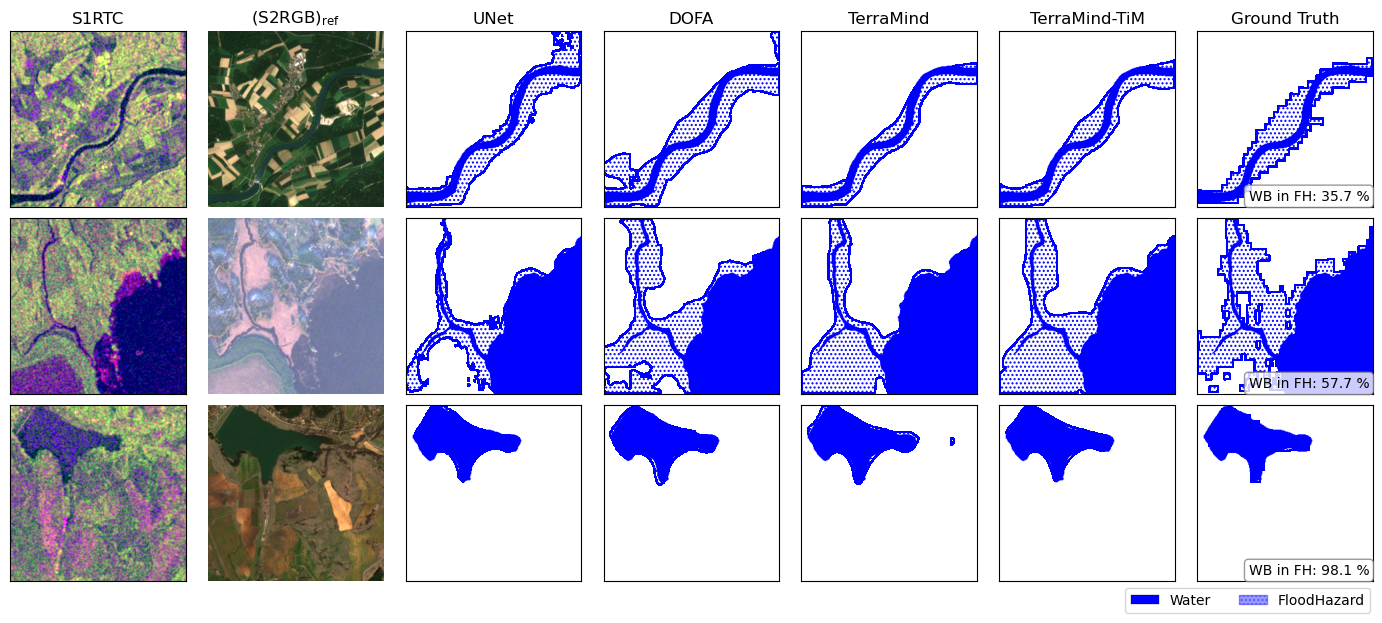

In [89]:
legend = viz_sample_multimodel_keys(
    sample_keys, 
    dataset_root/'val', 
    model_root_list, 
    model_name, 
    modalities=['S1RTC', 'S2RGB'],
    ref_modalities=['S2RGB'],
    fig_scale=2,
    show_legend=True,
    )
# plot_legend(legend, ncol=len(legend))

100%|██████████| 3/3 [00:00<00:00, 13.62it/s]


/dss/dsshome1/07/di54rur/kim_he/zeroflood-eusar/notebooks/utils.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  col_y = [col_y]


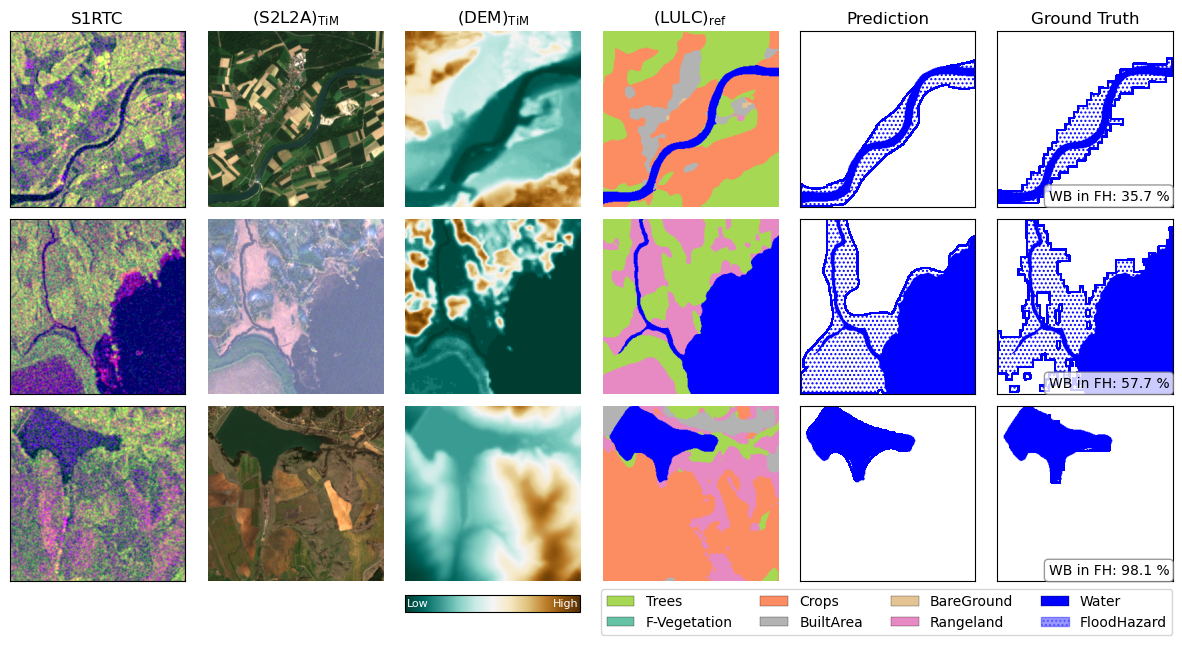

In [90]:
legend = viz_sample_keys(
    sample_keys, 
    dataset_root/'val', 
    model_root/'zeroflood-gfm-terramind-tim', 
    modalities=['S1RTC', 'S2RGB', 'DEM','LULC'], 
    tim_modalities=['S2RGB', 'DEM'],
    ref_modalities=['LULC'],
    fig_scale=2,
    show_legend=True,
    # save_img=True
    )
# plot_legend(legend, ncol=len(legend))